<a href="https://colab.research.google.com/github/ddezouza/Data201_DanielaMelo/blob/main/Melo_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2 - Predicting Abalone Age

#### Daniela Melo
#### April 30th, 2026

### Introduction

For Project 2, I looked for data sources that could reliably be used for regression and prediction. I stumbled upon UC Irvine's Machine Learning Repository, a collection of vetted datasets that can be downloaded and are reliably utilized for modeling and prediction tasks.

I originally majored in biology, and wanted to work with a dataset related to that field. The 'abalone'dataset consists of measurements of live 'abalone' and is intended to answer the question of how to predict an abalone's age using physical characteristics such as shel diameter, height, and length so as to not need the time consuming process of cutting and staining the shell to count the age predictor rings.

The dataset consists of measurements of these physical characteristics for over 4,000 abalone, as well as the number of age rings identified for each, so the dataset should give a solid basis from which to work with to generate a model for predicting the number of age rings for an abalone based on the other measured characteristics.

####Data source:
Nash, W., Sellers, T., Talbot, S., Cawthorn, A., & Ford, W. (1994). Abalone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55C7W
Retrieved April 26, 2026 from https://archive.ics.uci.edu/dataset/1/abalone

## Data Overview and Analysis Setup

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
import scipy

np.random.seed(42)

In [114]:
#Loading 'Abalone' dataset from Github Repository

df=pd.read_csv('https://raw.githubusercontent.com/ddezouza/Data201_DanielaMelo/refs/heads/main/Project2/abalone.csv')

#Dataframe dimensions
print( "Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:",df.shape[1])

Dataset shape: (4177, 9)
Rows: 4177
Columns: 9


In [115]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sex            4177 non-null   object 
 1   Length         4177 non-null   float64
 2   Diameter       4177 non-null   float64
 3   Height         4177 non-null   float64
 4   WholeWeight    4177 non-null   float64
 5   ShuckedWeight  4177 non-null   float64
 6   VisceraWeight  4177 non-null   float64
 7   ShellWeight    4177 non-null   float64
 8   Rings          4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


From df.info() we can see that the dataset has no missing values, and consists of one categorical variable (Sex) and eight numerical variables, as follows:

In [116]:
#Table f Variables:
pd.DataFrame({
    "Variable Name": ["Sex","Length","Diameter","Height","WholeWeight","ShuckedWeight","VisceraWeight","ShellWeight","Rings"],
    "Definition": ["Abalone sex (Male, Female, and Infant)","Longest shell measurement for abalone.","Shell measured perpendicular to length.","Abalone height with meat in shell.","Weight of whole abalone.","Weight of meat only, no shell.","Weight of viscera, removed.","Dried shell weight","Number of age rings identified (+1.5 gives abalone age in years)."],
    "Variable Type": ["Categorical","Numeric","Numeric","Numeric","Numeric","Numeric","Numeric","Numeric","Numeric"]
})

,Variable Name,Definition,Variable Type
0,Sex,"Abalone sex (Male, Female, and Infant)",Categorical
1,Length,Longest shell measurement for abalone.,Numeric
2,Diameter,Shell measured perpendicular to length.,Numeric
3,Height,Abalone height with meat in shell.,Numeric
4,WholeWeight,Weight of whole abalone.,Numeric
5,ShuckedWeight,"Weight of meat only, no shell.",Numeric
6,VisceraWeight,"Weight of viscera, removed.",Numeric
7,ShellWeight,Dried shell weight,Numeric
8,Rings,Number of age rings identified (+1.5 gives aba...,Numeric


## Data Exploration and Visualization

The first step when working with the dataset was to explore it through reviewing the variables, distributions and relationships available. I started by getting a birds eye view of summary statistics for the variables I was most interested in and reviweing the general association between variables through a pairwise plot.

In [117]:
#Overview of summary statistics
df.describe()

,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [118]:
#Means for Key Abalone Measurements
print(f'Mean Length:{np.mean(df['Length']):.6}')
print(f'Mean Diameter:{np.mean(df['Diameter']):.6}')
print(f'Mean Height:{np.mean(df['Height']):.6}')
print(f'Mean Whole Weight:{np.mean(df['WholeWeight']):.6}')
print(f'Mean Age:{np.mean(df['Rings'])+1.5:.6}')

Mean Length:0.523992
Mean Diameter:0.407881
Mean Height:0.139516
Mean Whole Weight:0.828742
Mean Age:11.4337


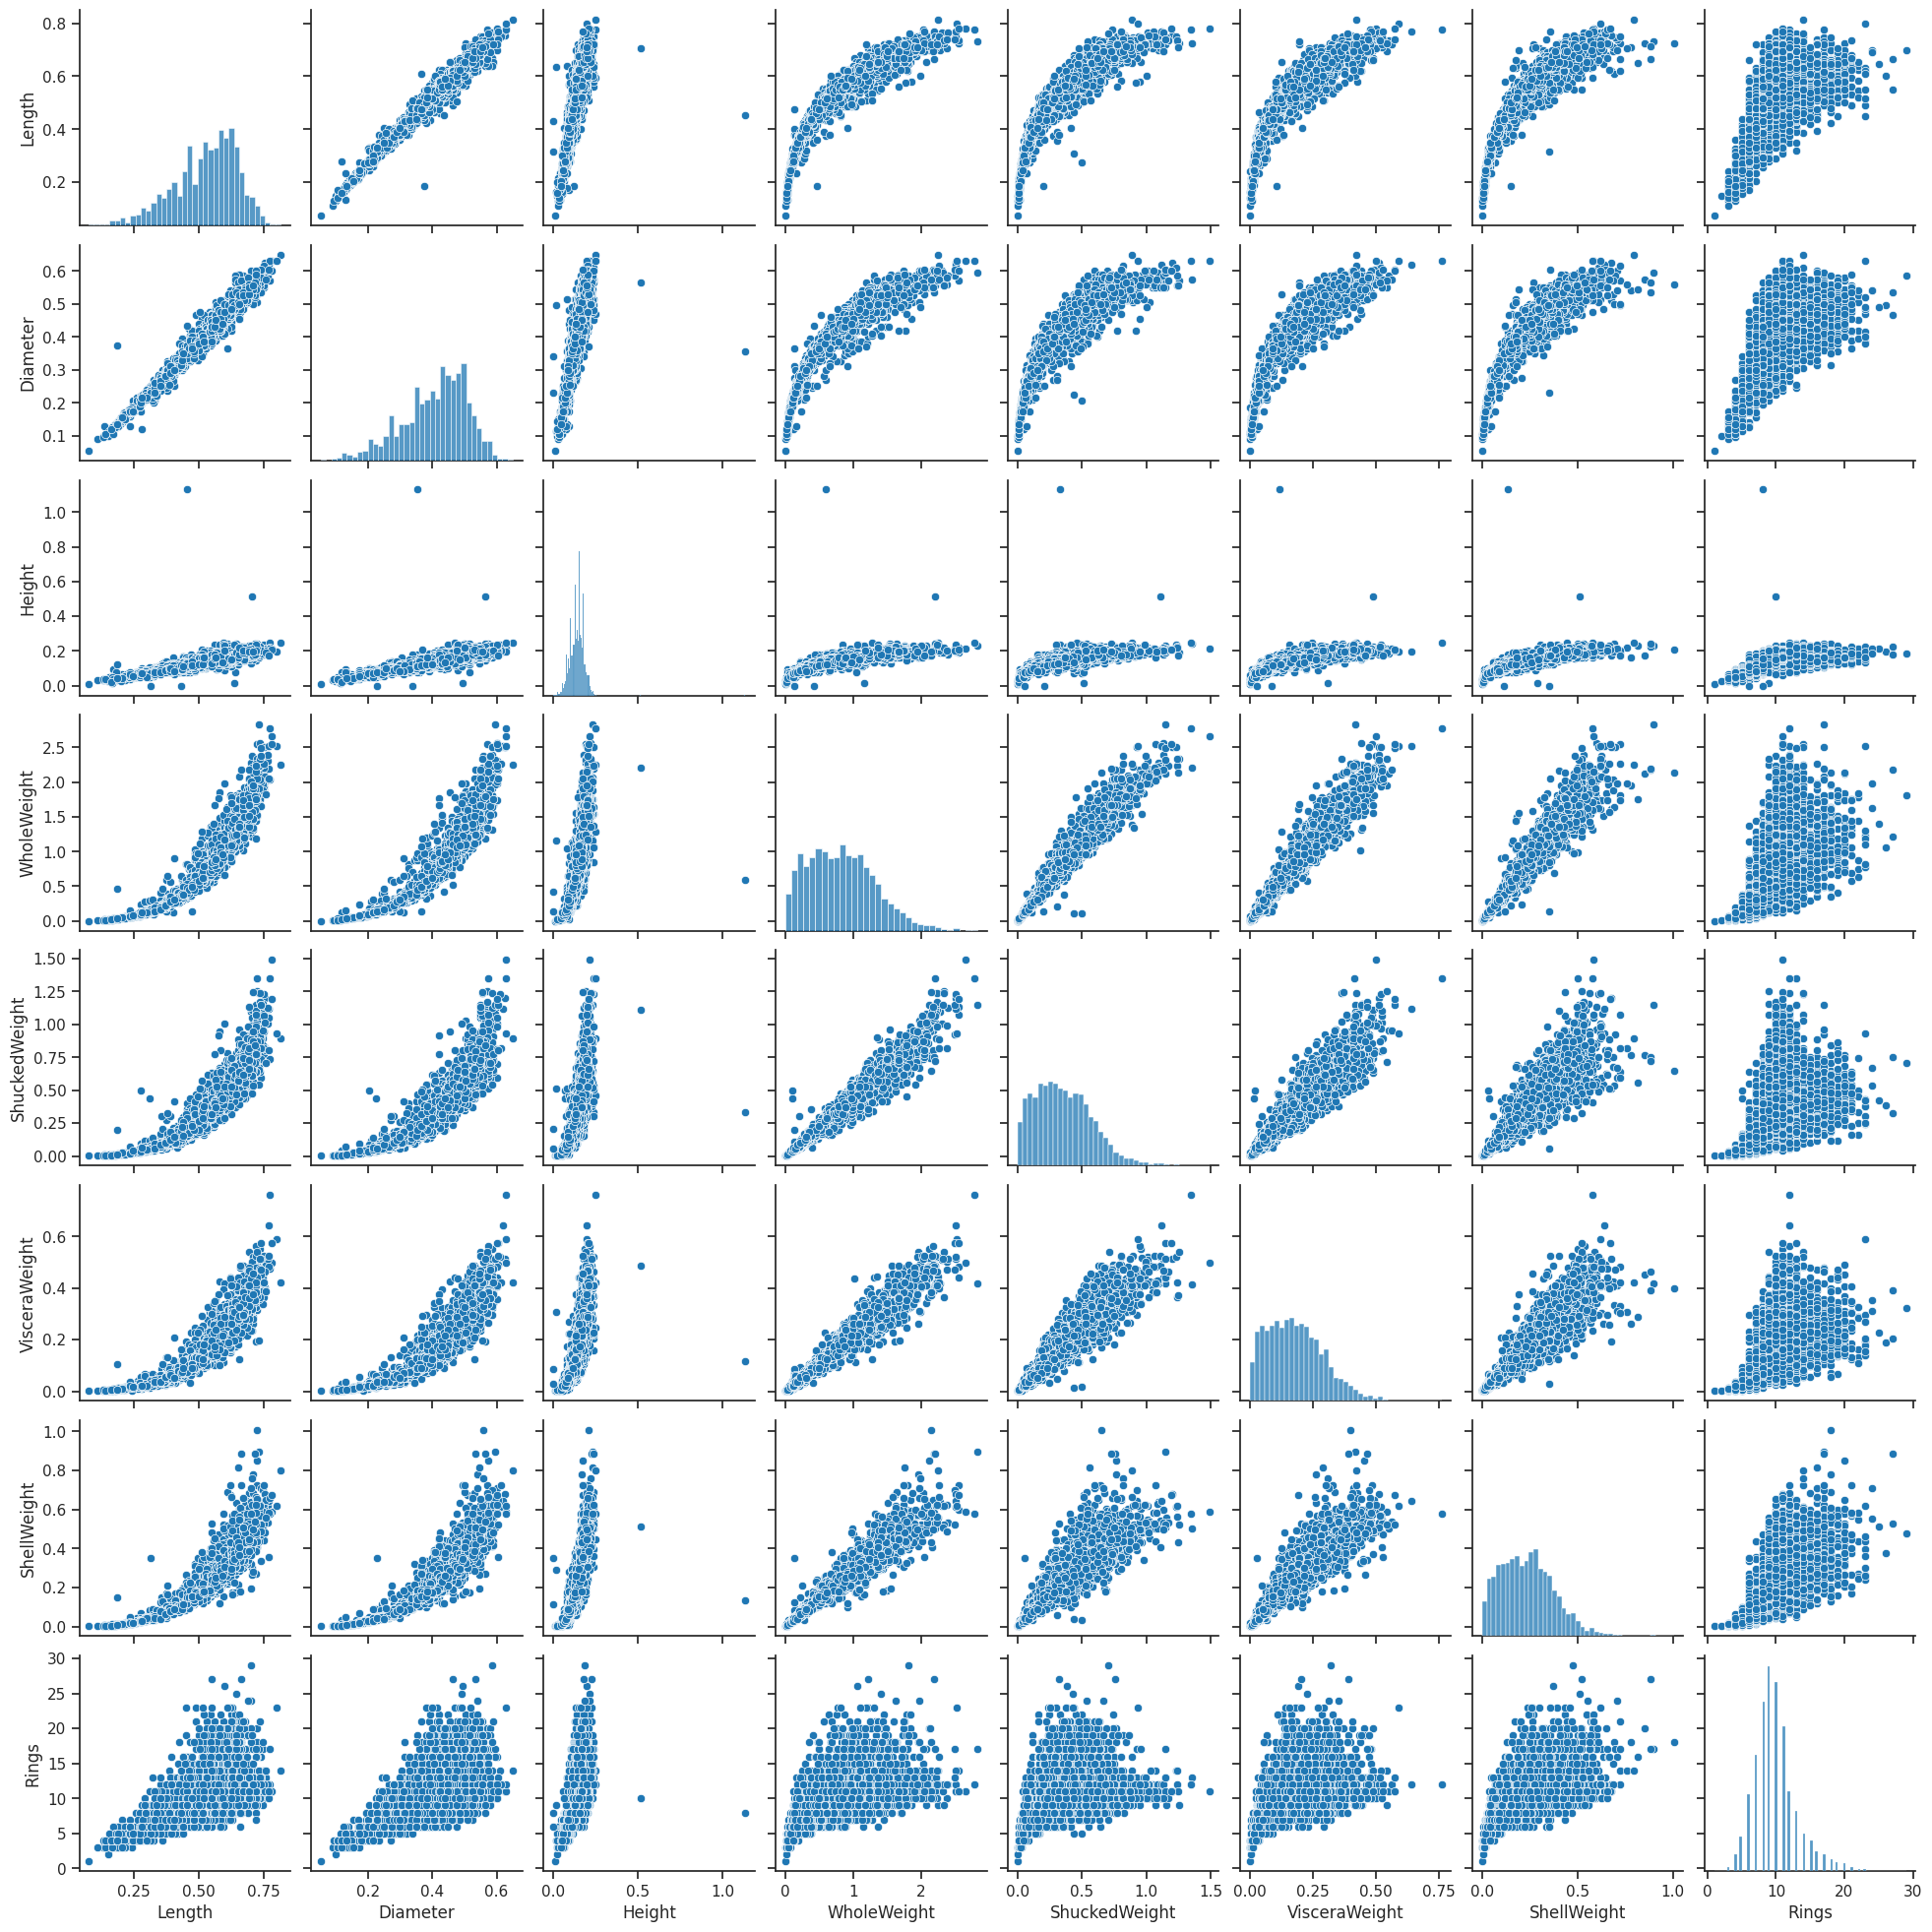

In [119]:
#Reviewing relationships through pairwise plot
sns.set_theme(style='ticks')
sns.set_palette('tab20')
sns.pairplot(df)
plt.show()

What becomes clear from the pairwise plot is that a lot of the variables have very strong relationships. Length and Diameter, for example, seem to have a  very strongly linear relationship, but a lot of the variables, especially when it comes to weight, have relationships that would require a curve to be properly described.

Most of the variables have slightly skewed distributions. The target variable I want to predict, for example (Rings) seems to be slightly right skewed. I chose to look at some of the distributions and paired variables in more detail.

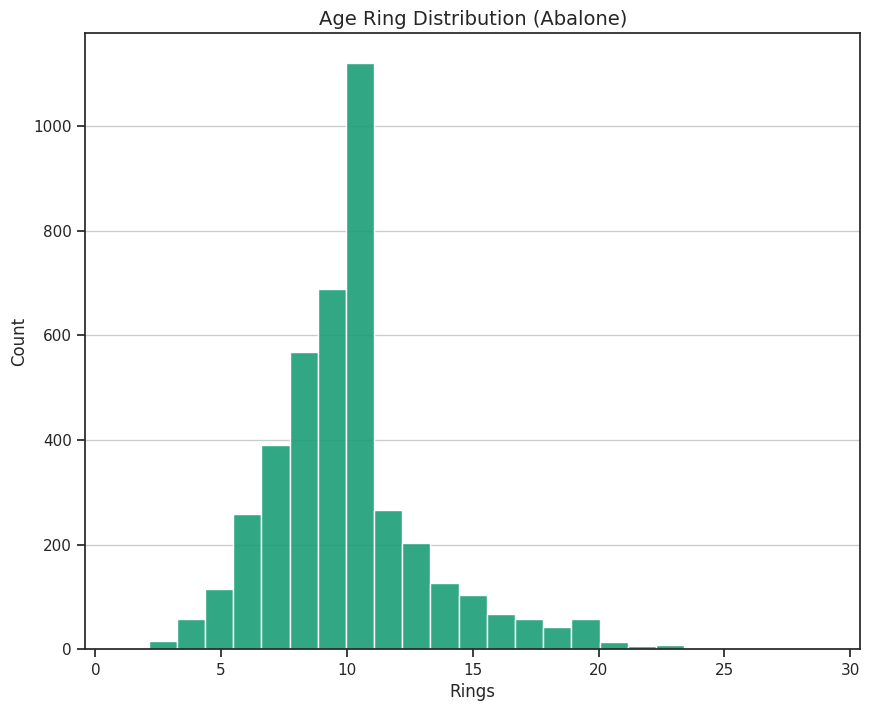

In [120]:
#Reviewing Distributions:
#Rings
plt.figure(figsize=(10,8))
sns.set_palette('Dark2')
sns.histplot(data=df,x='Rings',kde=False, alpha=.90, bins=25)
plt.xlabel('Rings', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Age Ring Distribution (Abalone)", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

In [121]:
print(f'Skewness for Rings: {scipy.stats.skew(df['Rings']):.3}')

Skewness for Rings: 1.11


A closer look at the distribution for the target variable Rings shows a relatively strong right skew (with skewness = 1.11).

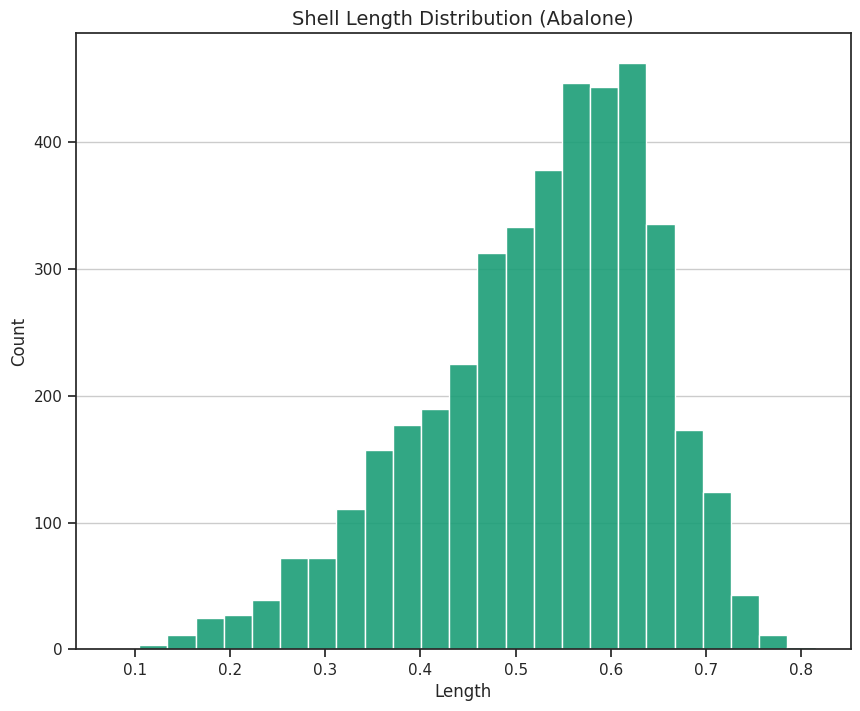

In [122]:
#Length
plt.figure(figsize=(10,8))
sns.set_palette('Dark2')
sns.histplot(data=df,x='Length',kde=False, alpha=.90, bins=25)
plt.xlabel('Length', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Shell Length Distribution (Abalone)", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

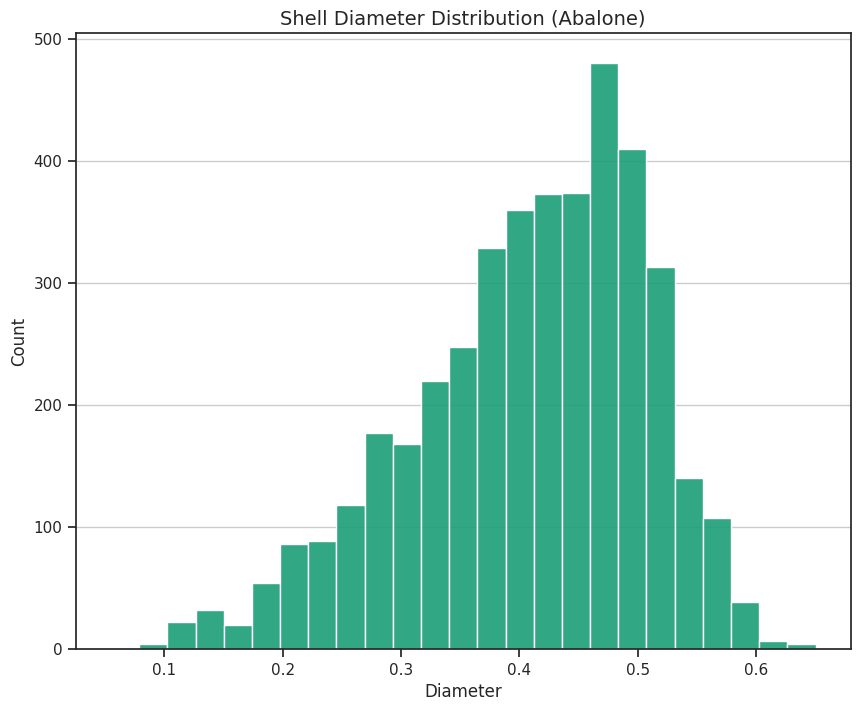

In [123]:
#Diameter
plt.figure(figsize=(10,8))
sns.set_palette('Dark2')
sns.histplot(data=df,x='Diameter',kde=False, alpha=.90, bins=25)
plt.xlabel('Diameter', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Shell Diameter Distribution (Abalone)", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

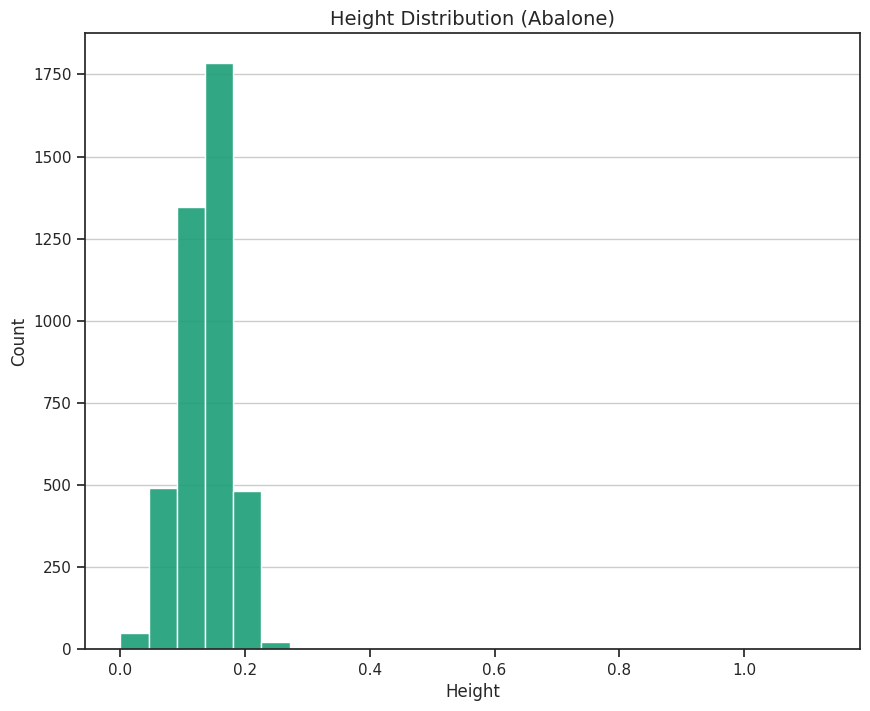

In [124]:
#Height
plt.figure(figsize=(10,8))
sns.set_palette('Dark2')
sns.histplot(data=df,x='Height',kde=False, alpha=.90, bins=25)
plt.xlabel('Height', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Height Distribution (Abalone)", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

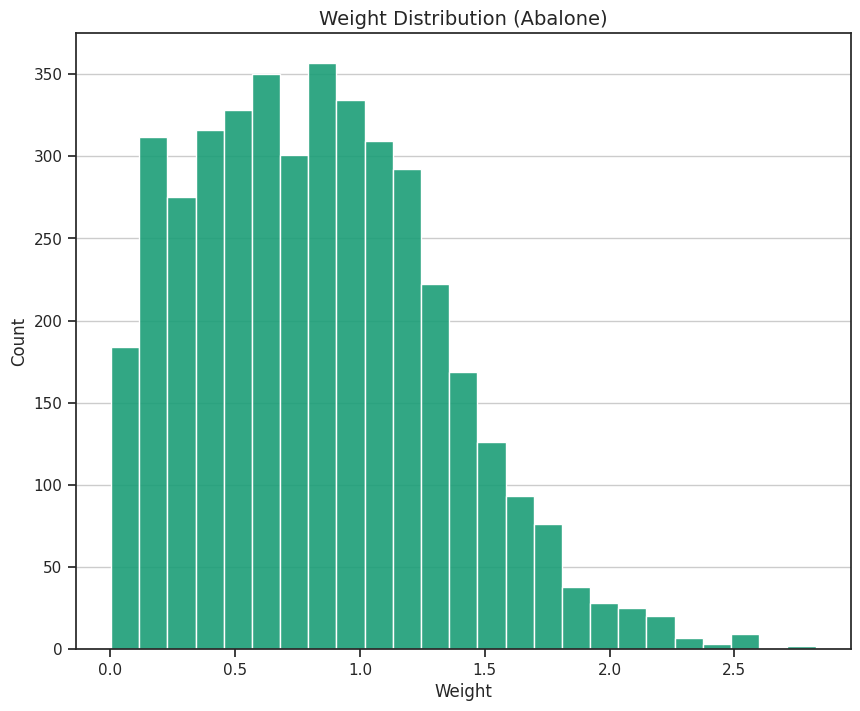

In [125]:
#WholeWeight
plt.figure(figsize=(10,8))
sns.set_palette('Dark2')
sns.histplot(data=df,x='WholeWeight',kde=False, alpha=.90, bins=25)
plt.xlabel('Weight', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title("Weight Distribution (Abalone)", fontsize=14)
plt.grid(True, axis='y',zorder=0)
plt.show()

In [126]:
print(f'Skewness for Length: {scipy.stats.skew(df['Length']):.3}')
print(f'Skewness for Diameter: {scipy.stats.skew(df['Diameter']):.3}')
print(f'Skewness for Height: {scipy.stats.skew(df['Height']):.3}')
print(f'Skewness for Whole Weight: {scipy.stats.skew(df['WholeWeight']):.3}')

Skewness for Length: -0.64
Skewness for Diameter: -0.609
Skewness for Height: 3.13
Skewness for Whole Weight: 0.531


Distributions for most of our predictive variables are all skewed to varying degrees. Length and Diameter are both skewed slightly left, as opposed to our target variable.

I chose to have a closer look at how closely shell diameter and shell  Length are related using a scatterplot, but I also wanted to see whether Sex, our only categorical variable, was a significant factor in what is essentially the size of the abalone.

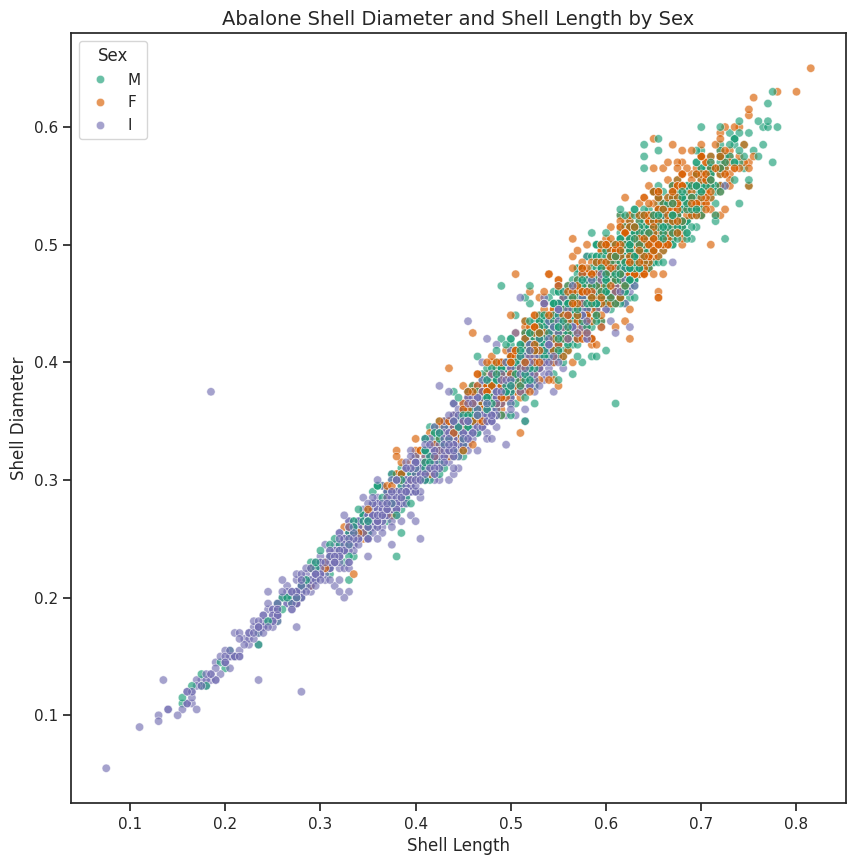

In [127]:
#Plotting Length vs. Diameter, with Sex
sns.set_palette('Dark2')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df, x='Length', y='Diameter', hue='Sex', alpha=0.65)
plt.xlabel('Shell Length', fontsize=12)
plt.ylabel('Shell Diameter', fontsize=12)
plt.title("Abalone Shell Diameter and Shell Length by Sex", fontsize=14)
plt.legend(title="Sex")
plt.show()

It is clear from the scatterplot that length and diameter are very strongly related - they are essentially colinear. It is likely that their value in predicting abalone age overlaps siginificantly and one or the other could be omitted from the model.  

I chose to include Shell Length and omit Shell Diameter from the model to avoid issues of collinearity.

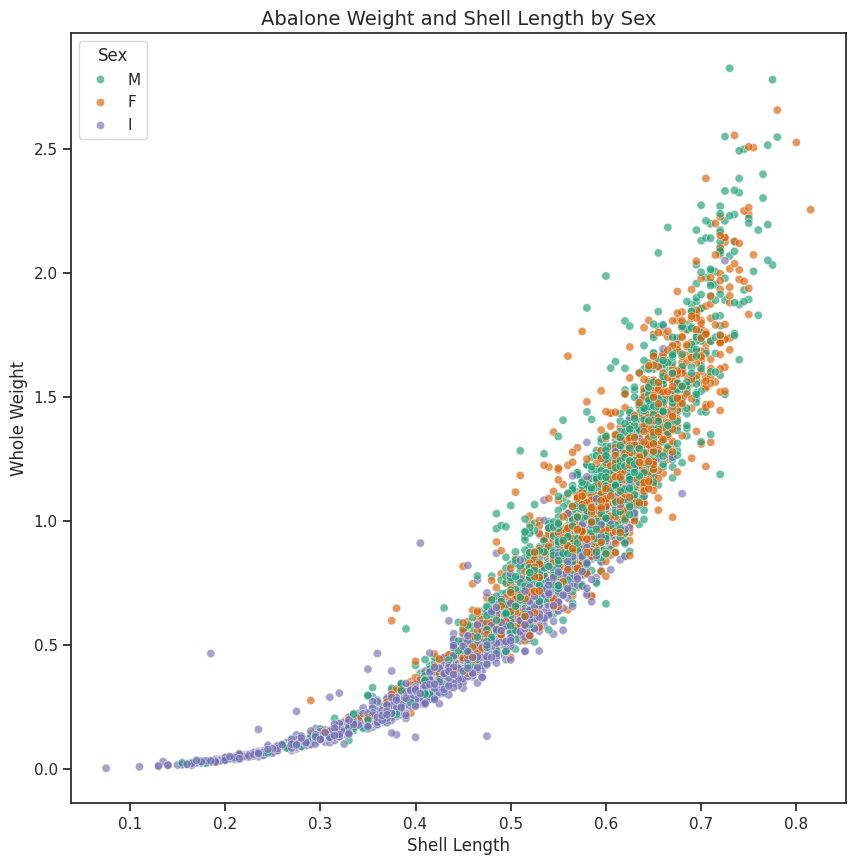

In [128]:
#Plotting Length vs. Weight, with Sex
sns.set_palette('Dark2')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df, x='Length', y='WholeWeight', hue='Sex', alpha=0.65)
plt.xlabel('Shell Length', fontsize=12)
plt.ylabel('Whole Weight', fontsize=12)
plt.title("Abalone Weight and Shell Length by Sex", fontsize=14)
plt.legend(title="Sex")
plt.show()

Weight and Shell Length are a lot less collinear, though there is still a clear relationship. The impact of Sex as a variable, however, is still not clear. There is a lot of overlap, though, predictably, infant abalone tend to be smaller in length and weight.

I want to know if Shell Lenght and Whole Weight can reliably be used to predict the number of age rings for Abalone, so I also chose to look at those relationships through different scatterplots.  

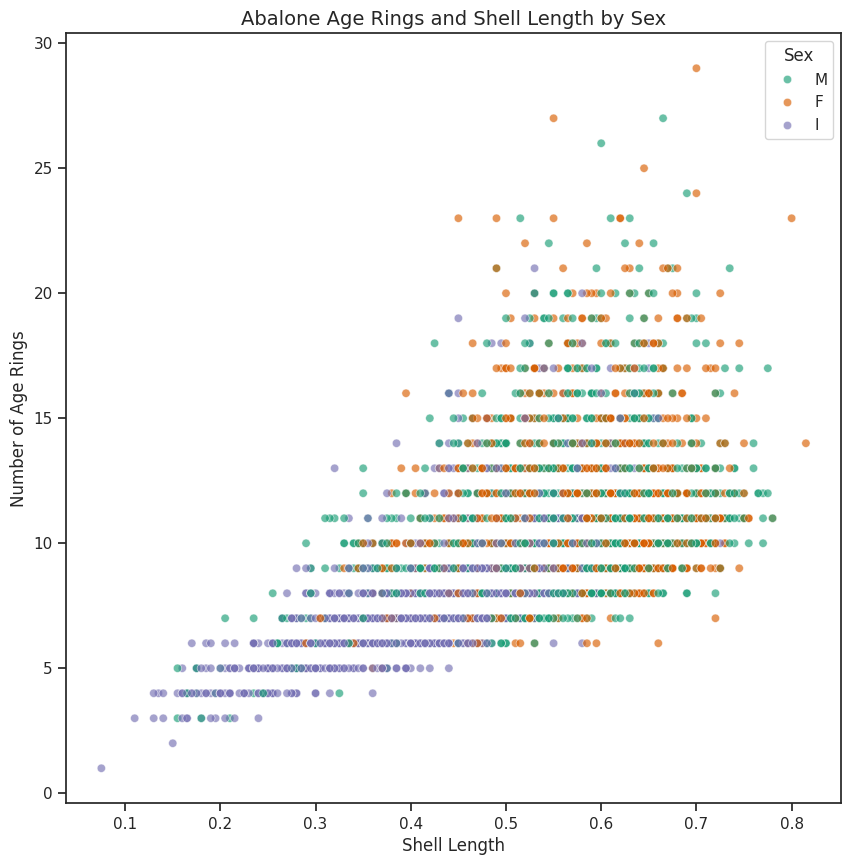

In [129]:
#Plotting Length vs. Rings, with Sex
sns.set_palette('Dark2')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df, x='Length', y='Rings', hue='Sex', alpha=0.65)
plt.xlabel('Shell Length', fontsize=12)
plt.ylabel('Number of Age Rings', fontsize=12)
plt.title("Abalone Age Rings and Shell Length by Sex", fontsize=14)
plt.legend(title="Sex")
plt.show()

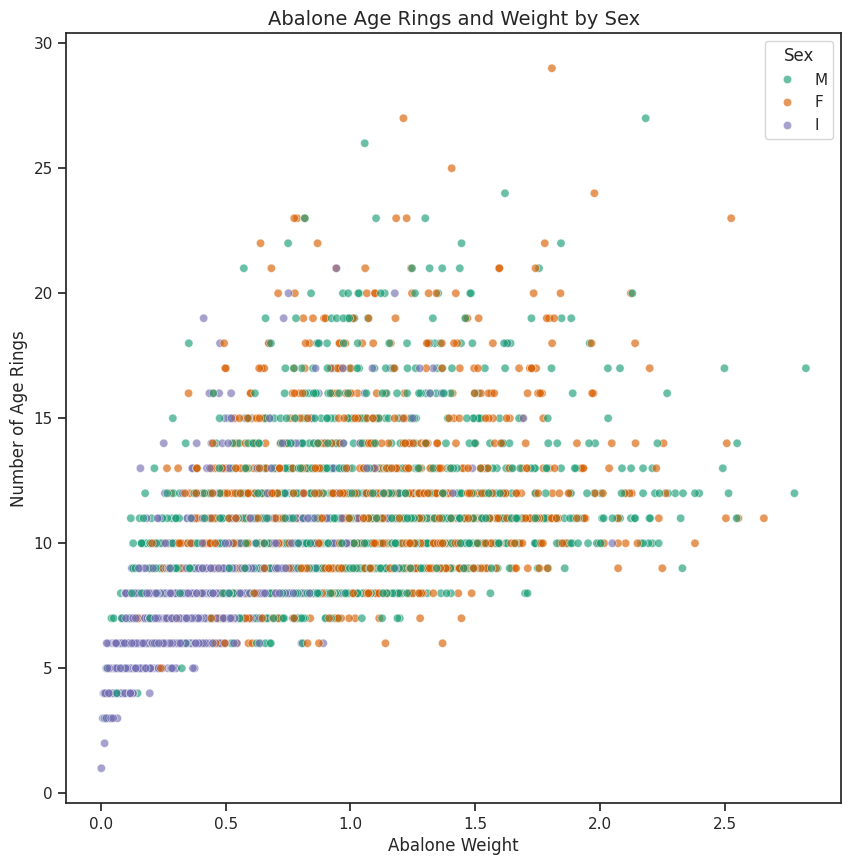

In [130]:
#Plotting Weight vs. Rings, with Sex
sns.set_palette('Dark2')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df, x='WholeWeight', y='Rings', hue='Sex', alpha=0.65)
plt.xlabel('Abalone Weight', fontsize=12)
plt.ylabel('Number of Age Rings', fontsize=12)
plt.title("Abalone Age Rings and Weight by Sex", fontsize=14)
plt.legend(title="Sex")
plt.show()

It is clear both Weight and Shell length are associated with the number of rings that can be identified for each abalone. This suggests they are good predictive variables. Outside of infant abalone, it does not look as though Sex has a significant relationship with either weight or shell length.

This indicates that a reliable model would encode sex to account for the infanct abalone.

## Train/Test Split

As recommended by most standards and lecture materials, I chose to use an 80/20 train/test split.

In [131]:
#X - variables of interest
#y - target variable (Rings - what I'm trying to predict)

X = df[["Height", "Length", "WholeWeight"]]
y = df["Rings"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


## Build a Baseline Model

For my baseline model, I chose to select shell length, whole weight, and height as the predictive variables, with Rings serving as the target variable.

In [132]:
BaseModel=LinearRegression()
BaseModel.fit(X_train,y_train)

LinearRegression()

In [133]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": BaseModel.coef_
})



,Feature,Coefficient
0,Height,21.109295
1,Length,6.928892
2,WholeWeight,0.469485


In [134]:
print(f'Model Intercept:{BaseModel.intercept_:.6}')

Model Intercept:2.96626


Based on the linear regression model, Height has the strongest relationship to Rings.

I evaluated the base model using RMSE and Rsquared:

In [135]:
# Predictions
y_pred = BaseModel.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print(f'RMSE:{rmse:.6}')
print(f'R squared:{r2:.6}')

RMSE:6.87354
R squared:0.365044


Based on R2 and RMSE, it does not look like the base linear model is a very good fit - it likely would have significant error in predicting the number of age rings for abalone.



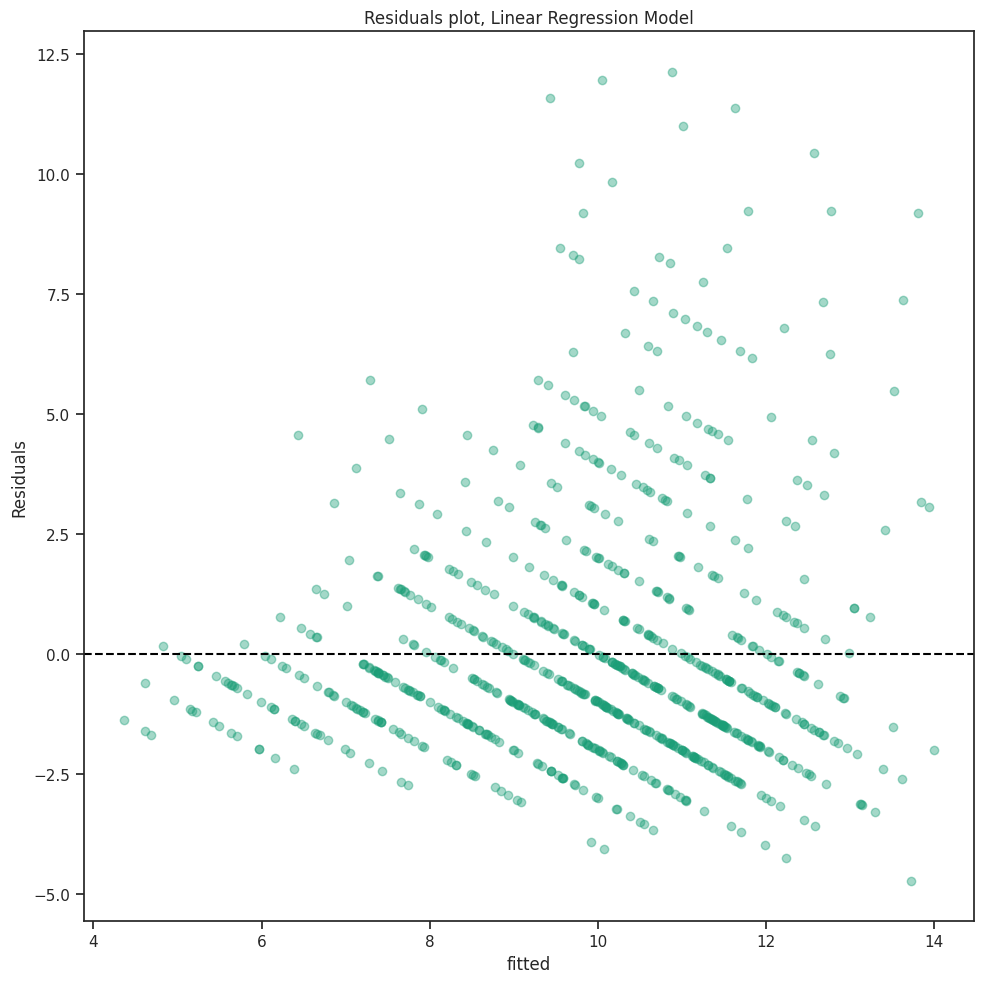

In [136]:
plt.figure(figsize=(10,10))
plt.scatter(y_pred,y_test - y_pred,alpha=0.4,label="Baseline model")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("fitted")
plt.ylabel("Residuals")
plt.title("Residuals plot, Linear Regression Model")
plt.tight_layout()
plt.show()


Model Residuals are not really centered at 0, highlighting how the model is not a good fit.

## Improving the Model

I chose to add sex as an added variable to the base linear model to see if I could account for the effect the smaller, infant abalone may be having. RMSE did improve somewhat, but the model is still not a great fit.

In [137]:
X = pd.concat([df[["Height", "Length", "WholeWeight"]],pd.get_dummies(df["Sex"], drop_first=True)],axis=1)#Sex is a categorical variable, so had to be hot-encoded
y = df["Rings"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [138]:
linSex = LinearRegression()
linSex.fit(X_train, y_train)

pred_linSex = linSex.predict(X_test)


In [139]:
r2_sex = r2_score(y_test, pred_linSex)
rmse_sex = mean_squared_error(y_test, pred_linSex)

print(f'RMSE:{rmse_sex:.6}')
print(f'R squared:{r2_sex:.6}')

RMSE:6.59456
R squared:0.390815


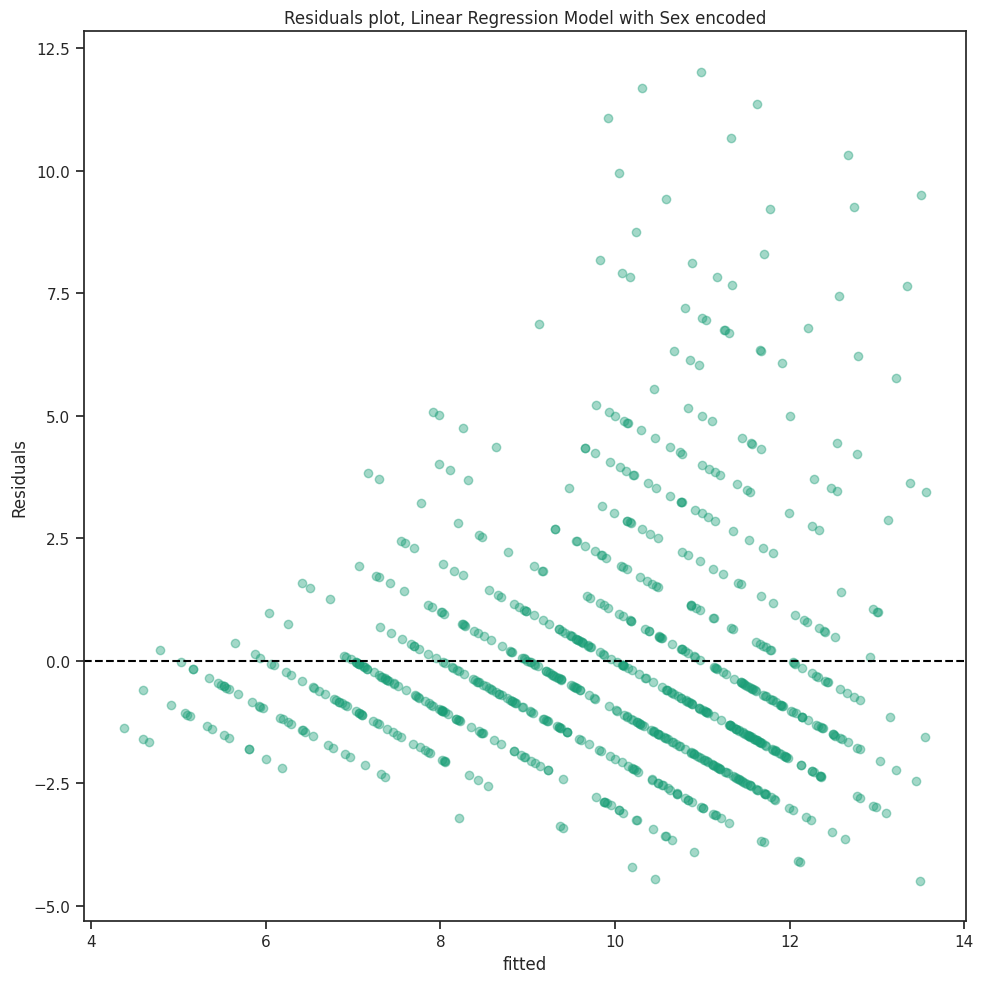

In [163]:
plt.figure(figsize=(10,10))
plt.scatter(pred_linSex,y_test - pred_linSex,alpha=0.4,label="Baseline model + Sex")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("fitted")
plt.ylabel("Residuals")
plt.title("Residuals plot, Linear Regression Model with Sex encoded")
plt.tight_layout()
plt.show()

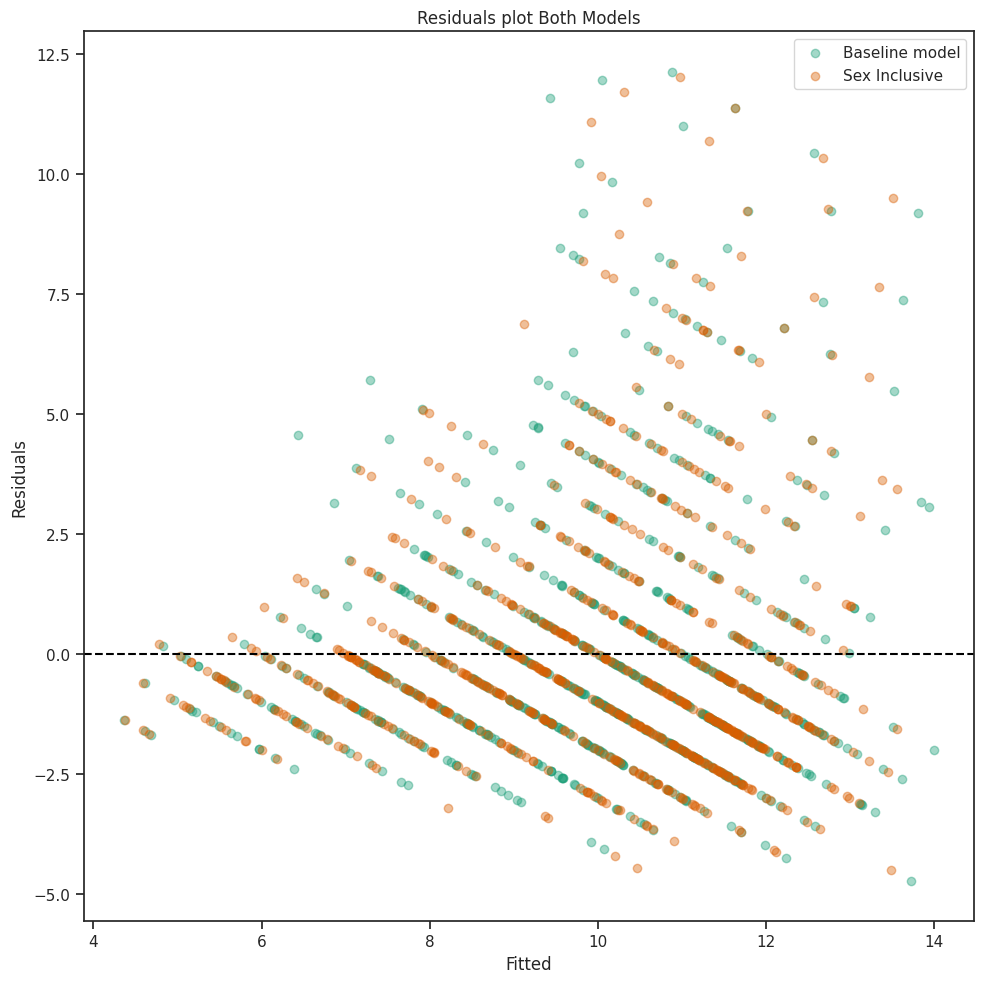

In [141]:
plt.figure(figsize=(10,10))
plt.scatter(y_pred,y_test - y_pred,alpha=0.4,label="Baseline model")
plt.scatter(pred_linSex,y_test - pred_linSex,alpha=0.4,label="Sex Inclusive")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.legend()
plt.title("Residuals plot Both Models")
plt.tight_layout()
plt.show()

## Further Improving the Model

Because the linear model was not a very good fit, indicating a potentially nonlinear relationship, a transformation seems to be necessary.

Multiple variables seemed to show exponential growth when plotted against one another (Shell length vs. Weight, for example). When looking at Number of Rings vs. Shell Length, a similar pattern emerges. The residuals of the base model also spread out more the larger the predicted rings value, which suggests a log transformation may work to improve the model.


In [142]:
#Log transformed model
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

LogModel = LinearRegression()
LogModel.fit(X_train, y_train_log)

# Predict and transform back
y_pred_log = LogModel.predict(X_test)
y_pred_log_back = np.exp(y_pred_log)


In [143]:
log_rmse = mean_squared_error(y_test, y_pred_log_back)
log_r2 = r2_score(y_test, y_pred_log_back)

print(f'RMSE:{log_rmse:.6}')
print(f'R squared:{log_r2:.6}')


RMSE:6.87157
R squared:0.365226


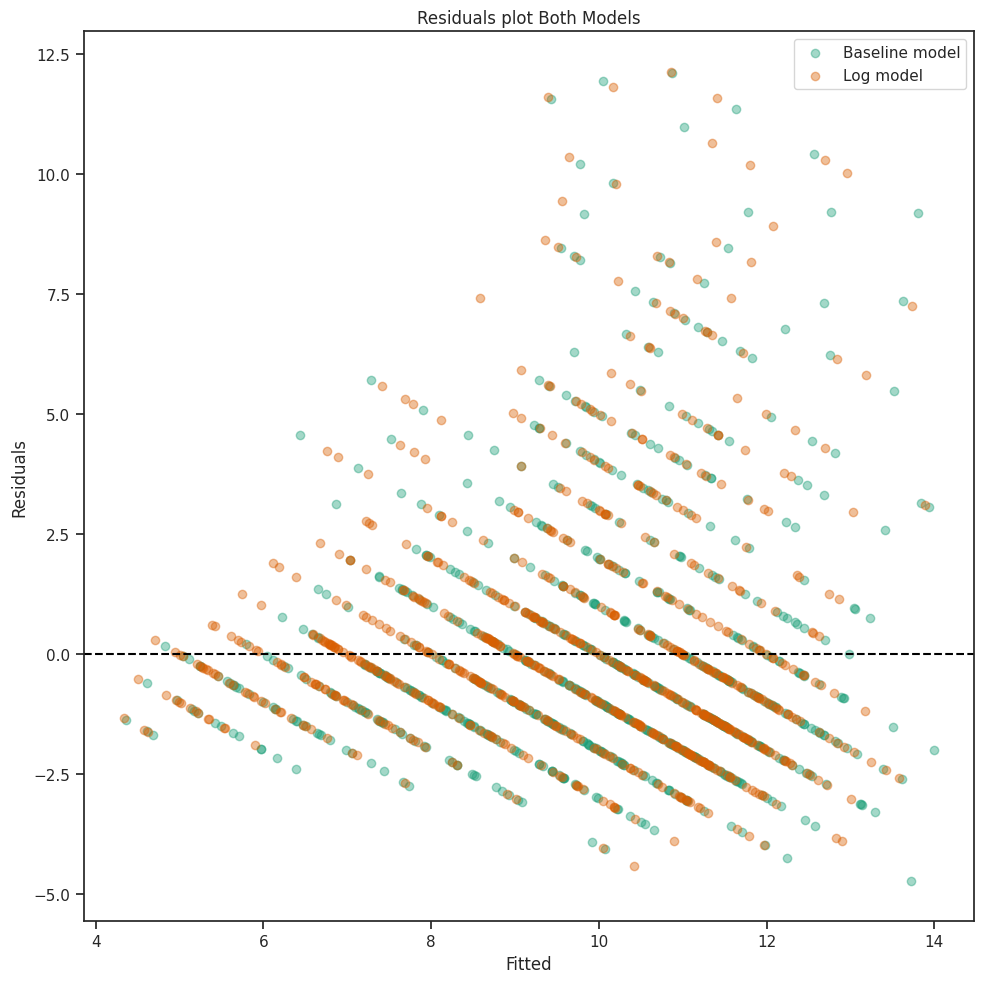

In [144]:
plt.figure(figsize=(10,10))
plt.scatter(y_pred,y_test - y_pred,alpha=0.4,label="Baseline model")
plt.scatter(y_pred_log_back,y_test - y_pred_log_back,alpha=0.4,label="Log model")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.legend()
plt.title("Residuals plot Both Models")
plt.tight_layout()
plt.show()


Unfortunately, the log model did not show much improvement. Residuals were still very spread with increased predicted ring values. Plotting both model residuals showcases they are equally bad.

I chose to test a third model, using a polynomial transformation.

In [145]:
#testing degree 2
PolyModel = Pipeline(
    [
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("linreg", LinearRegression())
    ]
)

PolyModel.fit(X_train, y_train)

y_pred_poly = PolyModel.predict(X_test)

poly_rmse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print(f'RMSE:{poly_rmse:.6}')
print(f'R squared:{poly_r2:.6}')


RMSE:6.54604
R squared:0.395297


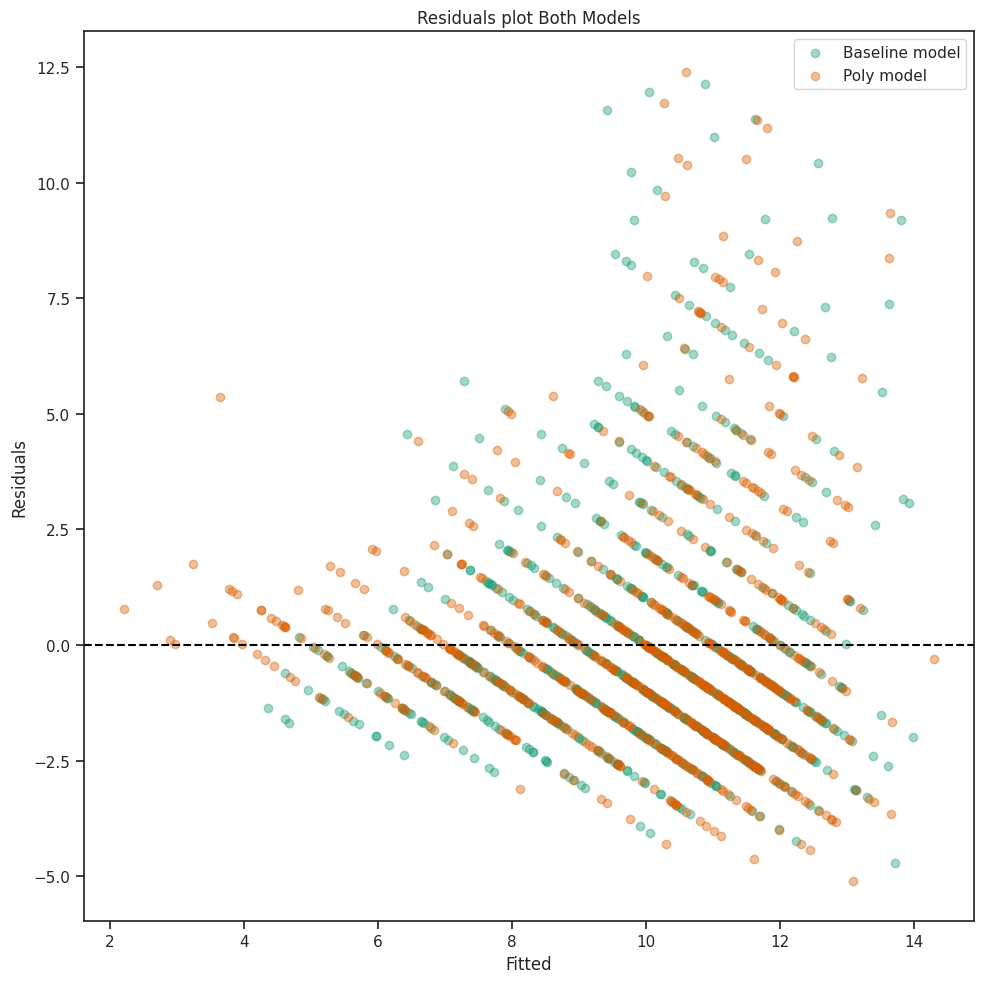

In [146]:
plt.figure(figsize=(10,10))
plt.scatter(y_pred,y_test - y_pred,alpha=0.4,label="Baseline model")
plt.scatter(y_pred_poly,y_test - y_pred_poly,alpha=0.4,label="Poly model")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.legend()
plt.title("Residuals plot Both Models")
plt.tight_layout()
plt.show()

The polynomial model was just a slight improvement on the base linear regression model. Residuals were slightly tighter, with R squared just slightly higher than the base model.

This suggests something is missing from the model. It is possible that additional variables or interactions may need to be accounted for.

Because my response data is a count outcome, esssentially the count of the number of age rings for each abalone, I then chose to try and use a Poisson regression instead of standard GLM.

In [147]:
from sklearn.linear_model import PoissonRegressor

In [148]:
PoissonModel = PoissonRegressor(alpha=0.0,max_iter=1000) #Because this is the first Poisson model I did not select an alpha for regularization; Regularization for this model can be finetuned later.
PoissonModel.fit(X_train, y_train)


PoissonRegressor(alpha=0.0, max_iter=1000)

In [149]:
Pois_pred = PoissonModel.predict(X_test)

pois_rmse = mean_squared_error(y_test, Pois_pred)
pois_r2 = r2_score(y_test, Pois_pred)#Rsquared is not really comparable to the other Rsquared values from the other models, so while I calculated it the basis of model comparison will be RMSE

print(f'RMSE:{pois_rmse:.6}')
print(f'R squared:{pois_r2:.6}')

RMSE:6.78119
R squared:0.373574


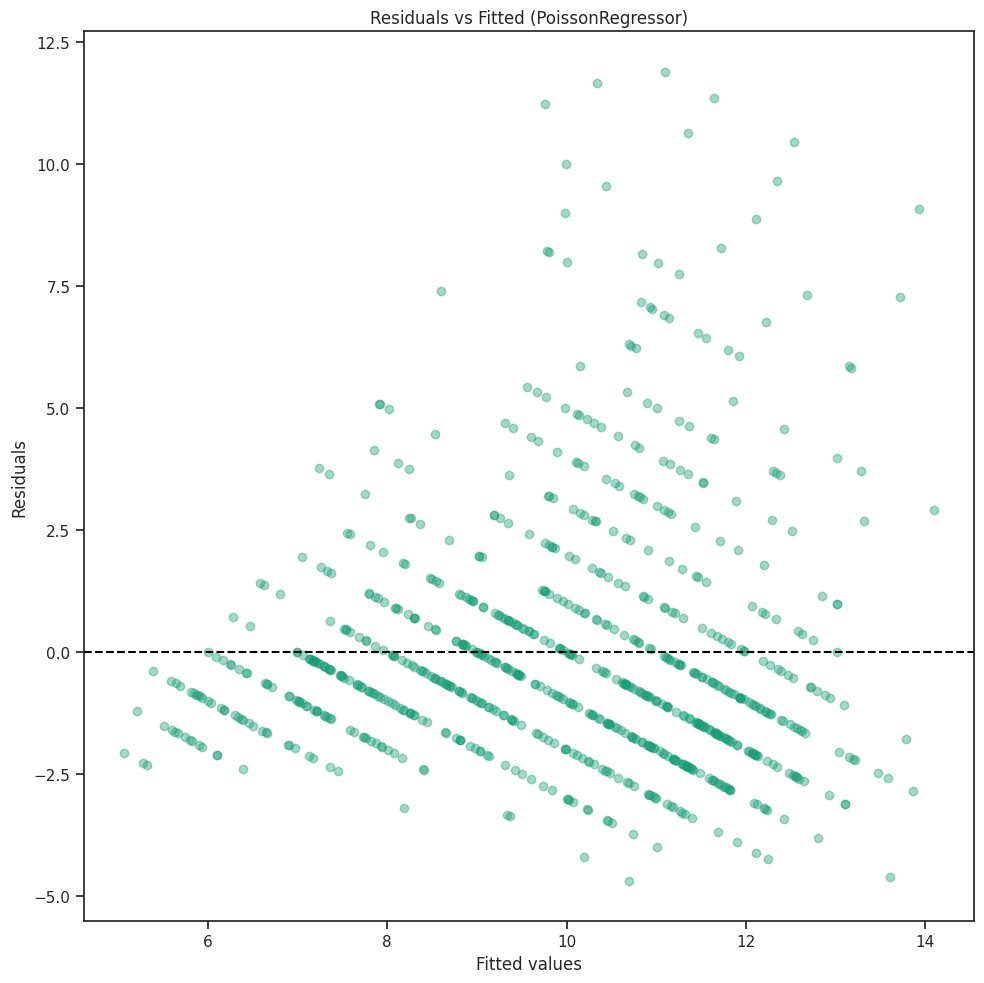

In [150]:
plt.figure(figsize=(10,10))
plt.scatter(Pois_pred, y_test-Pois_pred, alpha=0.4)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (PoissonRegressor)")
plt.tight_layout()
plt.show()


In [151]:
pd.DataFrame({
    "Model": ["Baseline Linear","Baseline + Sex","log","poly (2)","Poisson"],
    "RMSE": [rmse,rmse_sex,log_rmse,poly_rmse,pois_rmse],
    "R2": [r2,r2_sex,log_r2,poly_r2,pois_r2]
})

,Model,RMSE,R2
0,Baseline Linear,6.873537,0.365044
1,Baseline + Sex,6.594559,0.390815
2,log,6.871566,0.365226
3,poly (2),6.546039,0.395297
4,Poisson,6.781188,0.373574


## Predictions

In [152]:

FinalModel = PolyModel #Polynomial model had lowest RMSE
FinalModel.fit(X_train, y_train)


Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('linreg', LinearRegression())])

In [161]:
ThreeData = pd.DataFrame(
    {
        "Sex": ["F","I","M"],
        "Length": [0.47, 0.55, 0.68],
        "WholeWeight": [0.8, 0.9, 1.4],
        "Height": [0.15, 0.15, 0.18],
        }
)

ThreeDataFixed = pd.concat(
    [
        ThreeData[["Length", "WholeWeight", "Height"]],
        pd.get_dummies(ThreeData["Sex"], drop_first=True)
    ],
    axis=1)

#Ran into an issue with the order of my features, used copilot to troubleshoot and found reindexing the columns in my made up new datapoints worked
ThreeDataFixed = ThreeDataFixed.reindex(
    columns=X.columns,
    fill_value=0
)


In [162]:
FinalModel.predict(ThreeDataFixed)

array([11.59132682, 11.08499534, 11.17278553])

## Conclusions and Recommendations

Generally, I was unable to achieve a very successful model. While the model can be used to predict number of rings for abalone based on length, weight, and height, it is not a very good model.

The 2nd degree polynomial model is the best fitting model tested, but it still only explains ~ 39.5% of the variation in the data. This is kind of expected for biological data, and it does indicate that size and sex are actual predictors for age when you account for interaction terms. Still, it is possible that additional variables related to environment would need to be included in the model to further explain variability and allow for greater predictive power.